**Frequency VS Current Curve for the classic Hodgkin-Huxley neuron**  
We can find the gain function by sweeping the input (constant) current from 0 to 100  $\mu A/cm^2$ and plot the firing frequency vs $I_0$.  

**Notes:** 
1) We will use numba (JIT compiler) to increase the speed of computation by the implemented solver.
2) Capacitance can change the f-I curve profile, hence the plot includes various membrane capacitances.
3) A state-of-the-art solver like odeint or solve_ivp was not used due to their astronomical runtime for our parameter set.
4) Accuracy and runtime of our implemented solver was compared to solve_ivp.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numba import njit,prange

g_Na = 120 # mS/cm^2
g_K = 36 # mS/cm^2
g_L = 0.3 # mS/cm^2

E_Na = 50 # mV
E_K = -77 # mV
E_L = -54.4 # mV

u0 = -65 #mV ==> "initial potential"

max_time_res = 0.1 # ms
t0 = 0
tf = 1100 # ms

transient_time = 100 # ms

atol,rtol = 1e-6, 1e-3 # atol is the absolute error tolerance and rtol is the relative error tolerance.

In [ ]:
@njit
def alpha_n(u):
    return 0.01*(u+55)/(1-np.exp(-(u+55)/10))
@njit
def alpha_m(u):
    return 0.1*(u+40)/(1-np.exp(-(u+40)/10))
@njit
def alpha_h(u):
    return 0.07*np.exp(-(u+65)/20)
@njit
def beta_n(u):
    return 0.125*np.exp(-(u+65)/80)
@njit
def beta_m(u):
    return 4*np.exp(-(u+65)/18)
@njit
def beta_h(u):
    return 1/(np.exp(-(u+35)/10)+1)

**For a neuron at rest we have:** 


$0 = \alpha(u_0)\,(1-x_0)-\beta(u_0)\,x_0$  


therefore:  


$x_0 = \frac{\alpha}{\alpha+\beta}$

**Note**: Notation used for the equilibrium function $x_0$ instead of $x_\infty$ is based on Gerstner et al., Neuronal Dynamics (Ch. 2)

In [ ]:
m0 = alpha_m(u0)/(alpha_m(u0)+beta_m(u0))
h0 = alpha_h(u0)/(alpha_h(u0)+beta_h(u0))
n0 = alpha_n(u0)/(alpha_n(u0)+beta_n(u0))


**Defining the ODE function**

In [29]:
@njit
def func(t, vec , I, C):
    """ takes an array of [u,m,h,n] for a given Current & membrane capacitance. 
        outputs du/dt,dm/dt,dh/dt,dn/dt
    """

    du_dt = 1/C*(I - (
                        g_Na*vec[1]**3*vec[2]*(vec[0]-E_Na) +\
                        g_K*vec[3]**4*(vec[0]-E_K)  +\
                        g_L*(vec[0]-E_L)
                     )
                )
    
    dm_dt = alpha_m(vec[0])*(1-vec[1])-beta_m(vec[0])*vec[1]
    dh_dt = alpha_h(vec[0])*(1-vec[2])-beta_h(vec[0])*vec[2]
    dn_dt = alpha_n(vec[0])*(1-vec[3])-beta_n(vec[0])*vec[3]

    return np.array([du_dt,dm_dt,dh_dt,dn_dt])

**Implementation of RK45 (Dormand-Prince method)**  

 Dormand-Prince is the default method in the ode45 solver for MATLAB and GNU Octave and is the default choice for the Simulink's model explorer solver. It is an option in Python's SciPy ODE integration library and in Julia's ODE solvers library.  

 Here we have used the tableau made by Saul Teukolsky, William H. Press, and William T. Vetterling in their book Numerical Recipes, section called _Integration of Ordinary Differential Equations_. This source has a clear instruction for error handling and update method for the step-size.

In [28]:
@njit
def voltage_sol_RK45(I,C_m,func,initial_cond,t0,tf,transient_time,max_time_res,atol,rtol):
    """
    implementation of RK45 using https://numerical.recipes/book.html by William H. Press et. al.
    It returns membrane voltages during the time interval: transient_time to timulation time (t0)
    as a numpy array. max_time_res has a similar role to max_step in solve_ivp.
    """
    vec = initial_cond.copy() # to not mess with the initial condition later
    ans = [] # stores membrane voltages dueing the simulation time (ommiting the transient period)
    t = t0 # starting point
    dt = max_time_res # h in the RK5 algorithm
    S = 0.9 # safety factor S that is a few percent smaller than unity

    while t<tf: # at each loop we find the value for the next time step, hence t=tf is not included to prevent overshoot
        
        if not np.all(np.isfinite(vec)): # numba does not throw overflow errors since it is compiled
            raise FloatingPointError("NaN detected") # hence, we have to throw an error explicitly.

        if t + dt > tf: # Just to ensure we won't step beyond the simulation time.
            dt = tf - t
        
        while True:
            # K values:
            k1 = func(t ,vec, I, C_m)
            k2 = func(t+dt/5 ,vec+k1*dt/5, I, C_m)
            k3 = func(t+dt*3/10 ,vec+dt*(3/40*k1+9/40*k2), I, C_m)
            k4 = func(t+dt*4/5 ,vec+dt*(44/45*k1-56/15*k2+32/9*k3), I, C_m)
            k5 = func(t+dt*8/9 ,vec+dt*(19372/6561*k1-25360/2187*k2+64448/6561*k3-212/729*k4), I, C_m)
            k6 = func(t+dt ,vec+dt*(9017/3168*k1-355/33*k2+46732/5247*k3+49/176*k4-5103/18656*k5), I, C_m)
            k7 = func(t+dt ,vec+dt*(35/384*k1 + 500/1113*k3+125/192*k4-2187/6784*k5+11/84*k6), I, C_m)

            # vec_5th_ord is the fifth order y while vec_4th_ord is the 4th order y used for error estimation
            vec_5th_ord = vec + dt*(k1*35/384 +k3*500/1113+k4*125/192-k5*2187/6784+k6*11/84)
            vec_4th_ord = vec + dt*(k1*5179/57600+k3*7571/16695+k4*393/640-k5*92097/339200+k6*187/2100+k7/40)

            # Eucleadian distance of the solutions
            delta = np.abs(vec_5th_ord-vec_4th_ord)

            # To get the scaled error:
            scale = atol + max(np.linalg.norm(vec_5th_ord),np.linalg.norm(vec_4th_ord))*rtol
            error = 0.5*(np.linalg.norm(delta/scale)) # 0.5 factor is due to 1/(sqrt(ODE_dimension))

            if error<=1: # accept the step
                if error == 0:
                    new_dt = max_time_res # unlikely, but at least nothing blows up!

                else:
                    # updating the step, using the error, old dt and a safety factor S:
                    new_dt = S*dt*(error)**(-1/5)

                    # to prevent new_dt from becoming to small or too big:
                    if new_dt<0.2*dt:
                        new_dt = 0.2*dt
                    elif new_dt>max_time_res:
                        new_dt = max_time_res

                # Updating time parameters for the next step:
                t += dt
                dt = new_dt

                vec = vec_5th_ord # accepting y_5th_order_Runge_Kuta as the value for this step

                if t>= transient_time: 
                    ans.append(vec[0]) # storing membrane voltages only after the transient period
                    # This is to ensure system has had sufficent time to settle into its limit cycle
                break

            else: # when error is bigger than 1, only dt is updated, and inner loop repeats
                new_dt = S*dt*(error)**(-1/5)

                if new_dt<0.2*dt: # to ensure we won't reach singularity! dt --> 0 !
                    dt = 0.2*dt
                    
                else:
                    dt = new_dt # dt is updated

    return np.array(ans)

**Since current points are independent, we can run them in parallel using prange**  
In order to get the spike frequency from the membrane potential responce made by voltage_sol_RK45, we count the number of times voltage has crossed zero mV from below (negative to positive) and then devide it by the time interval (in second) to get the value of freqeuncy (in Hz).

In [30]:
@njit(parallel=True)
def fI_data(I_range,C_m,func,initial_cond,t0,tf,transient_time,max_time_res,atol,rtol):
    """Runs RK4 for the Current sweep"""

    freq = np.zeros_like(I_range) # To store the frequencies, somehow needed by numba!

    for i in prange(len(I_range)):
        V_response = voltage_sol_RK45(I_range[i], C_m,func,initial_cond,t0,tf,transient_time,max_time_res,atol,rtol)
        freq[i] = (sum(np.diff(np.sign(V_response)) == 2))*1000/(tf-transient_time)
        
    return freq

**Initial conditions for potential, gating variables, input current, and membrane capacitance.**

In [ ]:
vec0 = np.array([u0,m0,h0,n0],dtype=np.float64) # Initial condition
I_range = np.arange(0,100,0.1) # Currents we will sweep the model for.
C_m = [0.1,0.2,0.4,0.8,1.6,3.2,6.4] # μF/cm^2 , a list of membrane capacities for the plot.


**Storing the freqeuncy responces for our Current sweep and initial conditions:**

In [ ]:
responces = []
for C in C_m:
    responces.append(fI_data(I_range,C,func,vec0,t0,tf,transient_time,max_time_res,atol,rtol))

**The gain function of the Hodgkin–Huxley model**  

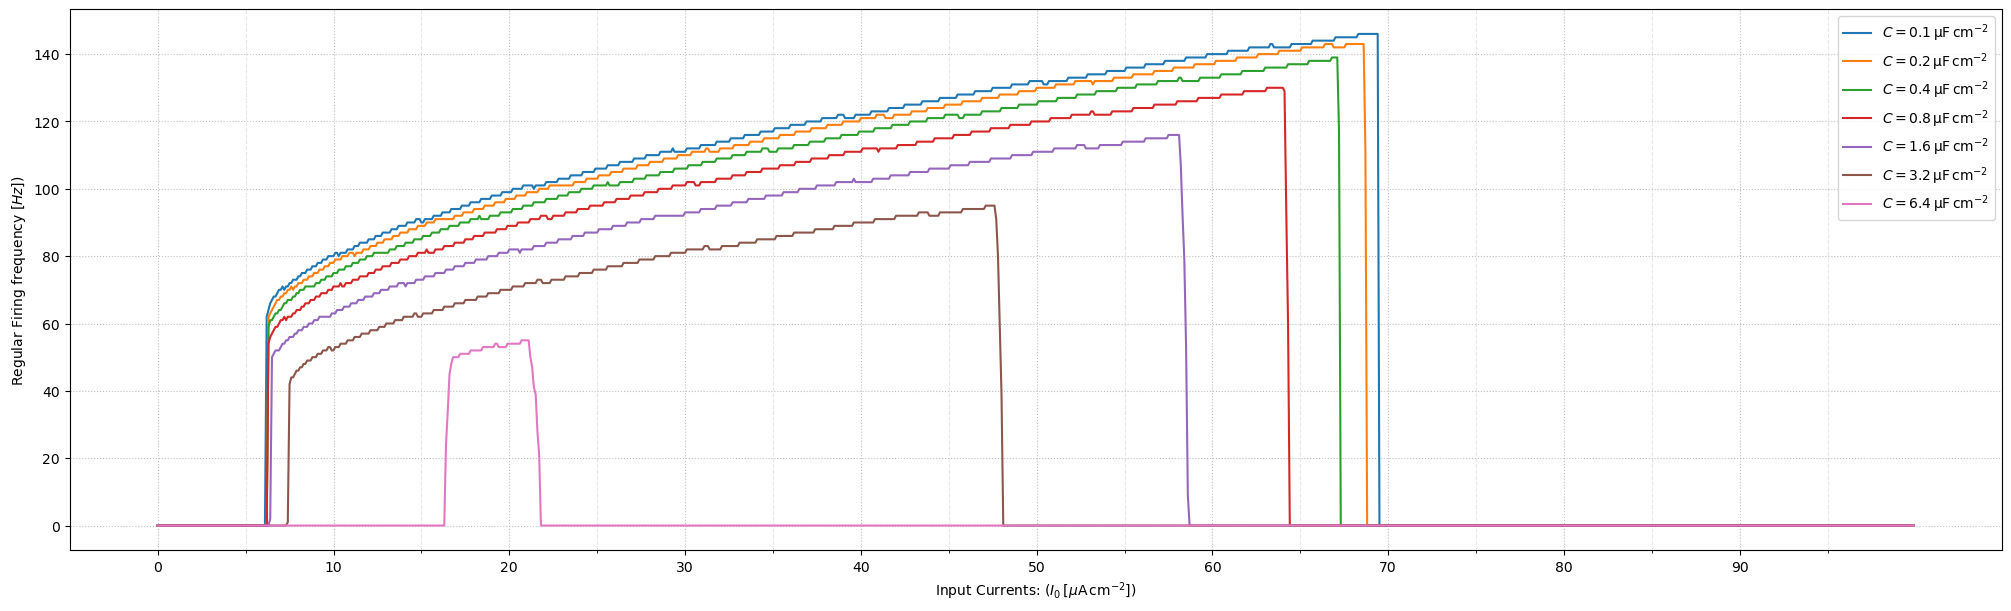

In [7]:
plt.figure(figsize=(20, 6), layout='constrained')

counter = 0

for ressponce in responces:

    plt.plot(I_range,ressponce,label=rf"$C = {C_m[counter]}\,\mathrm{{\mu F\,cm^{{-2}}}}$")

    counter +=1

x_freq_major_ticks = I_range[::100]
x_freq_minor_ticks = I_range[::50]

plt.xticks(x_freq_major_ticks)
plt.xticks(x_freq_minor_ticks, minor=True)
plt.grid(which='minor', alpha=0.3,linestyle='--')
plt.grid(which='major', alpha=0.8,linestyle=':')
plt.xlabel(r'Input Currents: ($I_0 \,[\mu\mathrm{A}\,\mathrm{cm}^{-2}]$)')
plt.ylabel(r'Regular Firing frequency $[Hz]$)')
plt.legend(loc="upper right")
plt.show()

**Checking the accuracy of voltage_sol_RK45 against state of the art solve_ivp from Scipy library:**

In [ ]:
C = 1 # μF/cm^2 # we will check it only for one value of capacitance
res_my_RK45 = fI_data(I_range,C,func,vec0,t0,tf,transient_time,max_time_res,atol,rtol)

In [ ]:
from scipy.integrate import solve_ivp

def scipy_solver(I_range,C,func,vec0,t0,tf,transient_time,max_time_res,atol,rtol):
    freq_scipy = []

    for i in I_range:
        # Solving the system of ODE via the same parameter set used by voltage_sol_RK45
        sol = solve_ivp(func,[t0, tf],vec0,method="RK45",max_step=max_time_res,rtol=rtol,atol=atol,args=(i,C,))

        scipy_response = sol.y[0][sol.t >= transient_time] # ommiting the voltages before transient period
        freq_scipy.append((sum(np.diff(np.sign(scipy_response)) == 2))*1000/(tf-transient_time)) # same as before
        
    return freq_scipy


**Comparison Plot**

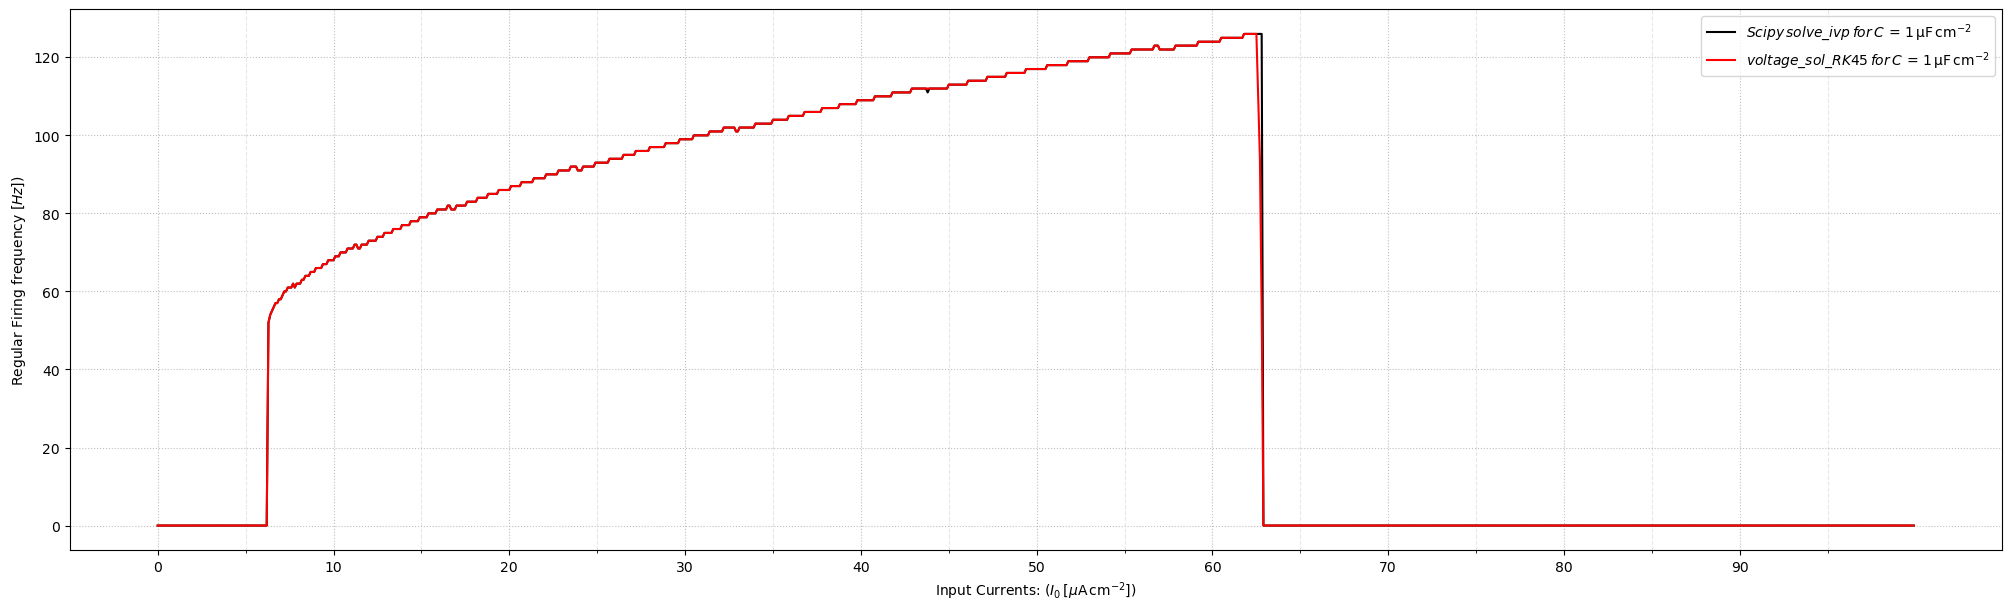

In [ ]:
plt.figure(figsize=(20, 6), layout='constrained')
scipy_ans = scipy_solver(I_range,C,func,vec0,t0,tf,transient_time,max_time_res,atol,rtol)
plt.plot(I_range,scipy_ans,"k",label=rf"$Scipy \, solve\_ivp \,for\, C \,= \, {C}\,\mathrm{{\mu F\,cm^{{-2}}}}$")
plt.plot(I_range,res_my_RK45,"r-",label=rf"$voltage\_sol\_RK45 \, for \, C \,=\, {C}\,\mathrm{{\mu F\,cm^{{-2}}}}$")

x_freq_major_ticks = I_range[::100]
x_freq_minor_ticks = I_range[::50]

plt.xticks(x_freq_major_ticks)
plt.xticks(x_freq_minor_ticks, minor=True)
plt.grid(which='minor', alpha=0.3,linestyle='--')
plt.grid(which='major', alpha=0.8,linestyle=':')
plt.xlabel(r'Input Currents: ($I_0 \,[\mu\mathrm{A}\,\mathrm{cm}^{-2}]$)')
plt.ylabel(r'Regular Firing frequency $[Hz]$)')
plt.legend(loc="upper right")
plt.show()

**Note:**  
Similar f-I curves aside, it is worth mentioning that the implemented solver performs very well in runtime benchmarks against solve_ivp:

In [21]:
C_test = 1 # μF/cm^2
I0_test = np.array([0,5,10,20,30,40,50,60,70,80])

In [22]:
%timeit fI_data( I0_test, C_test, func, vec0, t0, tf, transient_time, max_time_res, atol, rtol)

51.4 ms ± 2.17 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [23]:
%timeit scipy_solver(I0_test, C_test, func, vec0, t0, tf, transient_time, max_time_res, atol, rtol)

7.67 s ± 67.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


This indicates $\approx 150\times$ increase in speed (on my machine).